# Project 1: Data Analytics Using Pandas

This notebook uses a generated ecommerce dataset with **1000 records** and **10 columns**.
It includes:
- categorical and numerical columns
- a few missing values
- pandas practice tasks
- matplotlib / seaborn visualizations

## Dataset file
`ecommerce_data_1000.csv`

## Columns
1. `order_id`
2. `customer_id`
3. `category`
4. `subcategory`
5. `region`
6. `payment_method`
7. `unit_price`
8. `quantity`
9. `discount_pct`
10. `order_date`


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

df = pd.read_csv("ecommerce_data_1000.csv")
df["order_date"] = pd.to_datetime(df["order_date"])

# Derived columns for analysis
df["gross_amount"] = df["unit_price"] * df["quantity"]
df["discount_amount"] = df["gross_amount"] * (df["discount_pct"].fillna(0) / 100)
df["net_amount"] = df["gross_amount"] - df["discount_amount"]

df.head()


,order_id,customer_id,category,subcategory,region,payment_method,unit_price,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount
0,ORD00001,CUST1343,Electronics,Mobile,East,Card,3903.69,5,10.0,2025-06-08,19518.45,1951.845,17566.605
1,ORD00002,CUST1390,Fashion,Men,North,Wallet,3532.23,2,0.0,2025-07-12,7064.46,0.000,7064.460
2,ORD00003,CUST1051,Electronics,Accessory,West,UPI,3841.53,6,15.0,2025-07-07,23049.18,3457.377,19591.803
3,ORD00004,CUST1370,Electronics,Mobile,South,Card,2334.37,4,5.0,2025-03-08,9337.48,466.874,8870.606
4,ORD00005,CUST1177,Sports,Indoor,North,NaN,3272.75,3,20.0,2025-07-19,9818.25,1963.650,7854.600


## Task 1 - View first 5 rows
**Task:** Use a pandas method to display the first 5 rows.

In [4]:
display(df.head())

,order_id,customer_id,category,subcategory,region,payment_method,unit_price,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount
0,ORD00001,CUST1343,Electronics,Mobile,East,Card,3903.69,5,10.0,2025-06-08,19518.45,1951.845,17566.605
1,ORD00002,CUST1390,Fashion,Men,North,Wallet,3532.23,2,0.0,2025-07-12,7064.46,0.000,7064.460
2,ORD00003,CUST1051,Electronics,Accessory,West,UPI,3841.53,6,15.0,2025-07-07,23049.18,3457.377,19591.803
3,ORD00004,CUST1370,Electronics,Mobile,South,Card,2334.37,4,5.0,2025-03-08,9337.48,466.874,8870.606
4,ORD00005,CUST1177,Sports,Indoor,North,NaN,3272.75,3,20.0,2025-07-19,9818.25,1963.650,7854.600


## Task 2 - View last 5 rows
**Task:** Display the last 5 rows.

In [5]:
display(df.tail())

,order_id,customer_id,category,subcategory,region,payment_method,unit_price,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount
995,ORD00996,CUST1219,Electronics,Accessory,West,Cash on Delivery,1320.27,4,0.0,2025-12-18,5281.08,0.000,5281.080
996,ORD00997,CUST1316,Home,Furniture,West,Net Banking,927.64,2,15.0,2025-08-09,1855.28,278.292,1576.988
997,ORD00998,CUST1219,Electronics,Accessory,South,Cash on Delivery,4136.12,1,5.0,2025-11-30,4136.12,206.806,3929.314
998,ORD00999,CUST1262,Fashion,Kids,West,Cash on Delivery,2880.60,1,10.0,2025-10-29,2880.60,288.060,2592.540
999,ORD01000,CUST1039,Sports,Outdoor,South,Wallet,1168.92,6,20.0,2025-10-02,7013.52,1402.704,5610.816


## Task 3 - Check shape
**Task:** Find total rows and columns.

In [6]:
print(df.shape)

(1000, 13)


## Task 4 - Column names
**Task:** Display all column names.

In [7]:
print(df.columns)

Index(['order_id', 'customer_id', 'category', 'subcategory', 'region', 'payment_method', 'unit_price', 'quantity',
       'discount_pct', 'order_date', 'gross_amount', 'discount_amount', 'net_amount'],
      dtype='str')


## Task 5 - Data types
**Task:** Check data types of all columns.

In [8]:
print(df.columns)

Index(['order_id', 'customer_id', 'category', 'subcategory', 'region', 'payment_method', 'unit_price', 'quantity',
       'discount_pct', 'order_date', 'gross_amount', 'discount_amount', 'net_amount'],
      dtype='str')


## Task 6 - Summary info
**Task:** Get dataset information.

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_id         1000 non-null   str           
 1   customer_id      1000 non-null   str           
 2   category         1000 non-null   str           
 3   subcategory      985 non-null    str           
 4   region           980 non-null    str           
 5   payment_method   980 non-null    str           
 6   unit_price       1000 non-null   float64       
 7   quantity         1000 non-null   int64         
 8   discount_pct     985 non-null    float64       
 9   order_date       1000 non-null   datetime64[us]
 10  gross_amount     1000 non-null   float64       
 11  discount_amount  1000 non-null   float64       
 12  net_amount       1000 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(1), str(6)
memory usage: 142.4 KB


## Task 7 - Numerical summary
**Task:** Get descriptive statistics for numerical columns.

In [10]:
display(df.describe())

,unit_price,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount
count,1000.000000,1000.00000,985.000000,1000,1000.000000,1000.000000,1000.000000
mean,2560.824040,3.95900,9.989848,2025-06-24 22:23:31.200000,10204.718420,997.157674,9207.560746
min,152.760000,1.00000,0.000000,2025-01-01 00:00:00,210.480000,0.000000,178.908000
25%,1336.430000,2.00000,5.000000,2025-03-28 18:00:00,3564.335000,82.005750,3210.414000
50%,2483.825000,4.00000,10.000000,2025-06-20 00:00:00,8113.040000,548.834000,7235.700000
75%,3786.035000,6.00000,15.000000,2025-09-23 00:00:00,15313.275000,1346.376375,13957.345500
max,4994.320000,7.00000,20.000000,2025-12-31 00:00:00,34631.100000,6700.288000,33974.500000
std,1400.248721,1.96906,7.209827,NaN,8085.687101,1245.232146,7355.452735


## Task 8 - Include categorical summary
**Task:** Get descriptive statistics including object columns.

In [11]:
display(df.describe(include='all'))

,order_id,customer_id,category,subcategory,region,payment_method,unit_price,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount
count,1000,1000,1000,985,980,980,1000.000000,1000.00000,985.000000,1000,1000.000000,1000.000000,1000.000000
unique,1000,365,5,15,4,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,ORD00001,CUST1128,Beauty,Laptop,West,Card,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,10,206,78,252,201,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,2560.824040,3.95900,9.989848,2025-06-24 22:23:31.200000,10204.718420,997.157674,9207.560746
min,NaN,NaN,NaN,NaN,NaN,NaN,152.760000,1.00000,0.000000,2025-01-01 00:00:00,210.480000,0.000000,178.908000
25%,NaN,NaN,NaN,NaN,NaN,NaN,1336.430000,2.00000,5.000000,2025-03-28 18:00:00,3564.335000,82.005750,3210.414000
50%,NaN,NaN,NaN,NaN,NaN,NaN,2483.825000,4.00000,10.000000,2025-06-20 00:00:00,8113.040000,548.834000,7235.700000
75%,NaN,NaN,NaN,NaN,NaN,NaN,3786.035000,6.00000,15.000000,2025-09-23 00:00:00,15313.275000,1346.376375,13957.345500
max,NaN,NaN,NaN,NaN,NaN,NaN,4994.320000,7.00000,20.000000,2025-12-31 00:00:00,34631.100000,6700.288000,33974.500000


## Task 9 - Missing values
**Task:** Check missing values in each column.

In [12]:
display(df.isnull().sum())

order_id            0
customer_id         0
category            0
subcategory        15
region             20
payment_method     20
unit_price          0
quantity            0
discount_pct       15
order_date          0
gross_amount        0
discount_amount     0
net_amount          0
dtype: int64

## Task 10 - Total missing values
**Task:** Find total count of missing values in dataset.

In [13]:
print(df.isnull().sum().sum())

70


## Task 11 - Duplicate rows
**Task:** Check whether there are duplicate rows.

In [14]:
print(df.duplicated().sum())

0


## Task 12 - Unique categories
**Task:** Display unique values from category column.

In [15]:
print(df['category'].unique())

<ArrowStringArray>
['Electronics', 'Fashion', 'Sports', 'Beauty', 'Home']
Length: 5, dtype: str


## Task 13 - Count unique customers
**Task:** Find number of unique customers.

In [16]:
print(df['customer_id'].nunique())

365


## Task 14 - Value counts
**Task:** Count records per category.

In [17]:
display(df['category'].value_counts())

category
Beauty         206
Sports         205
Home           201
Electronics    197
Fashion        191
Name: count, dtype: int64

## Task 15 - Normalize value counts
**Task:** Find category proportions.

In [18]:
display(df['category'].value_counts(normalize=True))

category
Beauty         0.206
Sports         0.205
Home           0.201
Electronics    0.197
Fashion        0.191
Name: proportion, dtype: float64

## Task 16 - Sort by unit_price
**Task:** Sort dataset by unit_price descending.

In [19]:
display(df.sort_values(by='unit_price', ascending=False).head())

,order_id,customer_id,category,subcategory,region,payment_method,unit_price,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount
520,ORD00521,CUST1355,Sports,Outdoor,North,UPI,4994.32,4,15.0,2025-06-10,19977.28,2996.592,16980.688
224,ORD00225,CUST1238,Fashion,Kids,West,Net Banking,4988.26,6,15.0,2025-09-26,29929.56,4489.434,25440.126
770,ORD00771,CUST1153,Electronics,Accessory,North,Net Banking,4975.80,6,0.0,2025-05-24,29854.80,0.000,29854.800
526,ORD00527,CUST1355,Sports,Indoor,West,Wallet,4974.90,5,20.0,2025-02-13,24874.50,4974.900,19899.600
461,ORD00462,CUST1016,Fashion,Kids,West,Cash on Delivery,4968.68,4,20.0,2025-08-30,19874.72,3974.944,15899.776


## Task 17 - Filter Electronics
**Task:** Display rows where category is Electronics.

In [20]:
display(df[df['category'] == 'Electronics'].head())

,order_id,customer_id,category,subcategory,region,payment_method,unit_price,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount
0,ORD00001,CUST1343,Electronics,Mobile,East,Card,3903.69,5,10.0,2025-06-08,19518.45,1951.845,17566.605
2,ORD00003,CUST1051,Electronics,Accessory,West,UPI,3841.53,6,15.0,2025-07-07,23049.18,3457.377,19591.803
3,ORD00004,CUST1370,Electronics,Mobile,South,Card,2334.37,4,5.0,2025-03-08,9337.48,466.874,8870.606
9,ORD00010,CUST1273,Electronics,Mobile,West,UPI,362.45,4,0.0,2025-09-29,1449.80,0.000,1449.800
12,ORD00013,CUST1090,Electronics,Accessory,East,Wallet,780.12,5,10.0,2025-05-01,3900.60,390.060,3510.540


## Task 18 - Filter multiple conditions
**Task:** Show orders from South region with quantity greater than 3.

In [21]:
display(df[(df['region'] == 'South') & (df['quantity'] > 3)].head())

,order_id,customer_id,category,subcategory,region,payment_method,unit_price,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount
3,ORD00004,CUST1370,Electronics,Mobile,South,Card,2334.37,4,5.0,2025-03-08,9337.48,466.874,8870.606
8,ORD00009,CUST1186,Home,Kitchen,South,Cash on Delivery,3925.16,6,0.0,2025-05-13,23550.96,0.000,23550.960
13,ORD00014,CUST1333,Home,Decor,South,UPI,3398.60,7,10.0,2025-02-28,23790.20,2379.020,21411.180
17,ORD00018,CUST1265,Home,Furniture,South,Cash on Delivery,185.71,6,15.0,2025-10-12,1114.26,167.139,947.121
20,ORD00021,CUST1226,Home,Decor,South,Cash on Delivery,3391.75,5,10.0,2025-11-09,16958.75,1695.875,15262.875


## Task 19 - Select columns
**Task:** Display only order_id, category, unit_price, quantity.

In [22]:
display(df[['order_id', 'category', 'unit_price', 'quantity']].head())

,order_id,category,unit_price,quantity
0,ORD00001,Electronics,3903.69,5
1,ORD00002,Fashion,3532.23,2
2,ORD00003,Electronics,3841.53,6
3,ORD00004,Electronics,2334.37,4
4,ORD00005,Sports,3272.75,3


## Task 20 - iloc example
**Task:** Select first 10 rows and first 4 columns using iloc.

In [23]:
display(df.iloc[:10, :4])

,order_id,customer_id,category,subcategory
0,ORD00001,CUST1343,Electronics,Mobile
1,ORD00002,CUST1390,Fashion,Men
2,ORD00003,CUST1051,Electronics,Accessory
3,ORD00004,CUST1370,Electronics,Mobile
4,ORD00005,CUST1177,Sports,Indoor
5,ORD00006,CUST1025,Fashion,Kids
6,ORD00007,CUST1303,Beauty,Haircare
7,ORD00008,CUST1357,Fashion,Kids
8,ORD00009,CUST1186,Home,Kitchen
9,ORD00010,CUST1273,Electronics,Mobile


## Task 21 - loc example
**Task:** Select rows where category is Fashion and show selected columns using loc.

In [24]:
display(df.loc[df['category'] == 'Fashion', ['order_id', 'category', 'net_amount']].head())

,order_id,category,net_amount
1,ORD00002,Fashion,7064.460
5,ORD00006,Fashion,1126.899
7,ORD00008,Fashion,1495.560
19,ORD00020,Fashion,2908.390
36,ORD00037,Fashion,1976.000


## Task 22 - Fill missing discount
**Task:** Replace missing discount_pct with 0.

In [25]:
df['discount_pct'] = df['discount_pct'].fillna(0)
display(df.head())

,order_id,customer_id,category,subcategory,region,payment_method,unit_price,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount
0,ORD00001,CUST1343,Electronics,Mobile,East,Card,3903.69,5,10.0,2025-06-08,19518.45,1951.845,17566.605
1,ORD00002,CUST1390,Fashion,Men,North,Wallet,3532.23,2,0.0,2025-07-12,7064.46,0.000,7064.460
2,ORD00003,CUST1051,Electronics,Accessory,West,UPI,3841.53,6,15.0,2025-07-07,23049.18,3457.377,19591.803
3,ORD00004,CUST1370,Electronics,Mobile,South,Card,2334.37,4,5.0,2025-03-08,9337.48,466.874,8870.606
4,ORD00005,CUST1177,Sports,Indoor,North,NaN,3272.75,3,20.0,2025-07-19,9818.25,1963.650,7854.600


## Task 23 - Drop rows with missing region
**Task:** Create a copy after dropping rows with missing region.

In [26]:
df_region_dropped = df.dropna(subset=['region']).copy()
print(f"Original shape: {df.shape}, New shape: {df_region_dropped.shape}")

Original shape: (1000, 13), New shape: (980, 13)


## Task 24 - Rename columns
**Task:** Rename unit_price to price_per_unit in a copy.

In [27]:
df_renamed = df.rename(columns={'unit_price': 'price_per_unit'}).copy()
display(df_renamed.head())

,order_id,customer_id,category,subcategory,region,payment_method,price_per_unit,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount
0,ORD00001,CUST1343,Electronics,Mobile,East,Card,3903.69,5,10.0,2025-06-08,19518.45,1951.845,17566.605
1,ORD00002,CUST1390,Fashion,Men,North,Wallet,3532.23,2,0.0,2025-07-12,7064.46,0.000,7064.460
2,ORD00003,CUST1051,Electronics,Accessory,West,UPI,3841.53,6,15.0,2025-07-07,23049.18,3457.377,19591.803
3,ORD00004,CUST1370,Electronics,Mobile,South,Card,2334.37,4,5.0,2025-03-08,9337.48,466.874,8870.606
4,ORD00005,CUST1177,Sports,Indoor,North,NaN,3272.75,3,20.0,2025-07-19,9818.25,1963.650,7854.600


## Task 25 - Create month column
**Task:** Extract month name from order_date.

In [28]:
df['month'] = df['order_date'].dt.month_name()
display(df.head())

,order_id,customer_id,category,subcategory,region,payment_method,unit_price,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount,month
0,ORD00001,CUST1343,Electronics,Mobile,East,Card,3903.69,5,10.0,2025-06-08,19518.45,1951.845,17566.605,June
1,ORD00002,CUST1390,Fashion,Men,North,Wallet,3532.23,2,0.0,2025-07-12,7064.46,0.000,7064.460,July
2,ORD00003,CUST1051,Electronics,Accessory,West,UPI,3841.53,6,15.0,2025-07-07,23049.18,3457.377,19591.803,July
3,ORD00004,CUST1370,Electronics,Mobile,South,Card,2334.37,4,5.0,2025-03-08,9337.48,466.874,8870.606,March
4,ORD00005,CUST1177,Sports,Indoor,North,NaN,3272.75,3,20.0,2025-07-19,9818.25,1963.650,7854.600,July


## Task 26 - Create weekday column
**Task:** Extract day name from order_date.

In [29]:
df['weekday'] = df['order_date'].dt.day_name()
display(df.head())

,order_id,customer_id,category,subcategory,region,payment_method,unit_price,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount,month,weekday
0,ORD00001,CUST1343,Electronics,Mobile,East,Card,3903.69,5,10.0,2025-06-08,19518.45,1951.845,17566.605,June,Sunday
1,ORD00002,CUST1390,Fashion,Men,North,Wallet,3532.23,2,0.0,2025-07-12,7064.46,0.000,7064.460,July,Saturday
2,ORD00003,CUST1051,Electronics,Accessory,West,UPI,3841.53,6,15.0,2025-07-07,23049.18,3457.377,19591.803,July,Monday
3,ORD00004,CUST1370,Electronics,Mobile,South,Card,2334.37,4,5.0,2025-03-08,9337.48,466.874,8870.606,March,Saturday
4,ORD00005,CUST1177,Sports,Indoor,North,NaN,3272.75,3,20.0,2025-07-19,9818.25,1963.650,7854.600,July,Saturday


## Task 27 - Group by category
**Task:** Find mean net_amount by category.

In [30]:
display(df.groupby('category')['net_amount'].mean())

category
Beauty          9031.510590
Electronics     8819.793272
Fashion         8963.416183
Home            9017.927102
Sports         10170.509520
Name: net_amount, dtype: float64

## Task 28 - Group by category and region
**Task:** Find total net_amount by category and region.

In [31]:
display(df.groupby(['category', 'region'])['net_amount'].sum())

category     region
Beauty       East      285043.0900
             North     464625.2820
             South     537690.9255
             West      527870.3640
Electronics  East      522014.3090
             North     375541.3800
             South     447663.8885
             West      386056.5595
Fashion      East      518657.5150
             North     414741.0560
             South     384838.0485
             West      348922.4105
Home         East      586183.5265
             North     470123.7780
             South     372931.1165
             West      342695.9740
Sports       East      495416.0715
             North     568006.1110
             South     411999.1940
             West      523202.4630
Name: net_amount, dtype: float64

## Task 29 - Aggregate multiple metrics
**Task:** For each category compute sum, mean, and max of net_amount.

In [32]:
display(df.groupby('category')['net_amount'].agg(['sum', 'mean', 'max']))

,sum,mean,max
category,,,
Beauty,1.860491e+06,9031.510590,32319.0665
Electronics,1.737499e+06,8819.793272,31167.9900
Fashion,1.712012e+06,8963.416183,30125.1300
Home,1.812603e+06,9017.927102,30271.4300
Sports,2.084954e+06,10170.509520,33974.5000


## Task 30 - Pivot table
**Task:** Create pivot table of average net_amount by category and region.

In [33]:
display(df.pivot_table(values='net_amount', index='category', columns='region', aggfunc='mean'))

region,East,North,South,West
category,,,,
Beauty,5938.397708,9482.148612,10145.111802,9959.818189
Electronics,11863.961568,8733.520465,8446.488462,7019.210173
Fashion,9604.768796,8640.438667,9386.293866,7930.054784
Home,11272.760125,8247.785579,9323.277912,7291.403702
Sports,11009.246033,10717.096434,8583.316542,9871.744585


## Task 31 - Crosstab
**Task:** Create crosstab for category vs payment_method.

In [34]:
display(pd.crosstab(df['category'], df['payment_method']))

payment_method,Card,Cash on Delivery,Net Banking,UPI,Wallet
category,,,,,
Beauty,40,41,38,43,40
Electronics,48,41,40,28,35
Fashion,38,36,42,34,37
Home,34,45,31,47,42
Sports,41,34,39,41,45


## Task 32 - Top 10 expensive orders
**Task:** Find top 10 rows by unit_price.

In [35]:
display(df.nlargest(10, 'unit_price'))

,order_id,customer_id,category,subcategory,region,payment_method,unit_price,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount,month,weekday
520,ORD00521,CUST1355,Sports,Outdoor,North,UPI,4994.32,4,15.0,2025-06-10,19977.28,2996.592,16980.688,June,Tuesday
224,ORD00225,CUST1238,Fashion,Kids,West,Net Banking,4988.26,6,15.0,2025-09-26,29929.56,4489.434,25440.126,September,Friday
770,ORD00771,CUST1153,Electronics,Accessory,North,Net Banking,4975.80,6,0.0,2025-05-24,29854.80,0.000,29854.800,May,Saturday
526,ORD00527,CUST1355,Sports,Indoor,West,Wallet,4974.90,5,20.0,2025-02-13,24874.50,4974.900,19899.600,February,Thursday
461,ORD00462,CUST1016,Fashion,Kids,West,Cash on Delivery,4968.68,4,20.0,2025-08-30,19874.72,3974.944,15899.776,August,Saturday
59,ORD00060,CUST1299,Fashion,Men,South,Wallet,4963.02,2,20.0,2025-02-03,9926.04,1985.208,7940.832,February,Monday
923,ORD00924,CUST1319,Beauty,Skincare,North,UPI,4956.35,2,0.0,2025-04-20,9912.70,0.000,9912.700,April,Sunday
181,ORD00182,CUST1179,Fashion,Kids,West,Net Banking,4953.06,5,0.0,2025-07-03,24765.30,0.000,24765.300,July,Thursday
180,ORD00181,CUST1335,Electronics,Accessory,South,UPI,4947.30,7,10.0,2025-03-15,34631.10,3463.110,31167.990,March,Saturday
786,ORD00787,CUST1332,Electronics,Laptop,South,Net Banking,4947.10,3,0.0,2025-07-28,14841.30,0.000,14841.300,July,Monday


## Task 33 - nlargest example
**Task:** Find top 5 highest net_amount orders.

In [36]:
display(df.nlargest(5, 'net_amount'))

,order_id,customer_id,category,subcategory,region,payment_method,unit_price,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount,month,weekday
987,ORD00988,CUST1236,Sports,Outdoor,North,UPI,4853.50,7,0.0,2025-09-29,33974.50,0.0000,33974.5000,September,Monday
738,ORD00739,CUST1045,Sports,Outdoor,West,Wallet,4623.43,7,0.0,2025-11-24,32364.01,0.0000,32364.0100,November,Monday
689,ORD00690,CUST1201,Beauty,Skincare,East,Cash on Delivery,4860.01,7,5.0,2025-11-18,34020.07,1701.0035,32319.0665,November,Tuesday
180,ORD00181,CUST1335,Electronics,Accessory,South,UPI,4947.30,7,10.0,2025-03-15,34631.10,3463.1100,31167.9900,March,Saturday
983,ORD00984,CUST1310,Electronics,Mobile,East,Wallet,4395.18,7,0.0,2025-02-04,30766.26,0.0000,30766.2600,February,Tuesday


## Task 34 - nsmallest example
**Task:** Find 5 lowest unit_price orders.

In [37]:
display(df.nsmallest(5, 'unit_price'))

,order_id,customer_id,category,subcategory,region,payment_method,unit_price,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount,month,weekday
612,ORD00613,CUST1307,Sports,NaN,South,Net Banking,152.76,5,10.0,2025-05-14,763.80,76.3800,687.4200,May,Wednesday
910,ORD00911,CUST1222,Beauty,Skincare,East,Card,163.13,5,5.0,2025-03-14,815.65,40.7825,774.8675,March,Friday
270,ORD00271,CUST1397,Beauty,Makeup,East,Net Banking,169.44,7,0.0,2025-07-21,1186.08,0.0000,1186.0800,July,Monday
258,ORD00259,CUST1247,Sports,Fitness,North,Card,173.00,2,20.0,2025-07-14,346.00,69.2000,276.8000,July,Monday
766,ORD00767,CUST1379,Home,Decor,West,Net Banking,173.56,7,15.0,2025-12-27,1214.92,182.2380,1032.6820,December,Saturday


## Task 35 - Query example
**Task:** Use query to get Home category orders with quantity >= 2.

In [38]:
display(df.query("category == 'Home' and quantity >= 2").head())

,order_id,customer_id,category,subcategory,region,payment_method,unit_price,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount,month,weekday
8,ORD00009,CUST1186,Home,Kitchen,South,Cash on Delivery,3925.16,6,0.0,2025-05-13,23550.96,0.000,23550.960,May,Tuesday
10,ORD00011,CUST1130,Home,Furniture,East,UPI,3762.10,3,20.0,2025-05-30,11286.30,2257.260,9029.040,May,Friday
13,ORD00014,CUST1333,Home,Decor,South,UPI,3398.60,7,10.0,2025-02-28,23790.20,2379.020,21411.180,February,Friday
16,ORD00017,CUST1079,Home,Furniture,East,Card,3460.10,5,0.0,2025-10-31,17300.50,0.000,17300.500,October,Friday
17,ORD00018,CUST1265,Home,Furniture,South,Cash on Delivery,185.71,6,15.0,2025-10-12,1114.26,167.139,947.121,October,Sunday


## Task 36 - Between example
**Task:** Find rows where unit_price is between 500 and 1500.

In [39]:
display(df[df['unit_price'].between(500, 1500)].head())

,order_id,customer_id,category,subcategory,region,payment_method,unit_price,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount,month,weekday
5,ORD00006,CUST1025,Fashion,Kids,West,Card,1252.11,1,10.0,2025-11-21,1252.11,125.211,1126.899,November,Friday
12,ORD00013,CUST1090,Electronics,Accessory,East,Wallet,780.12,5,10.0,2025-05-01,3900.60,390.060,3510.540,May,Thursday
30,ORD00031,CUST1178,Sports,Fitness,West,Net Banking,888.71,4,15.0,2025-06-30,3554.84,533.226,3021.614,June,Monday
34,ORD00035,CUST1311,Home,Furniture,South,Net Banking,1439.47,6,20.0,2025-04-07,8636.82,1727.364,6909.456,April,Monday
36,ORD00037,CUST1182,Fashion,Kids,North,Cash on Delivery,617.50,4,20.0,2025-02-16,2470.00,494.000,1976.000,February,Sunday


## Task 37 - isin example
**Task:** Find orders paid via UPI or Card.

In [40]:
display(df[df['payment_method'].isin(['UPI', 'Card'])].head())

,order_id,customer_id,category,subcategory,region,payment_method,unit_price,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount,month,weekday
0,ORD00001,CUST1343,Electronics,Mobile,East,Card,3903.69,5,10.0,2025-06-08,19518.45,1951.845,17566.605,June,Sunday
2,ORD00003,CUST1051,Electronics,Accessory,West,UPI,3841.53,6,15.0,2025-07-07,23049.18,3457.377,19591.803,July,Monday
3,ORD00004,CUST1370,Electronics,Mobile,South,Card,2334.37,4,5.0,2025-03-08,9337.48,466.874,8870.606,March,Saturday
5,ORD00006,CUST1025,Fashion,Kids,West,Card,1252.11,1,10.0,2025-11-21,1252.11,125.211,1126.899,November,Friday
6,ORD00007,CUST1303,Beauty,Haircare,East,UPI,4164.01,2,15.0,2025-03-02,8328.02,1249.203,7078.817,March,Sunday


## Task 38 - String contains
**Task:** Find subcategories containing 'care'.

In [41]:
display(df[df['subcategory'].str.contains('care', case=False, na=False)].head())

,order_id,customer_id,category,subcategory,region,payment_method,unit_price,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount,month,weekday
6,ORD00007,CUST1303,Beauty,Haircare,East,UPI,4164.01,2,15.0,2025-03-02,8328.02,1249.203,7078.817,March,Sunday
11,ORD00012,CUST1075,Beauty,Haircare,North,Net Banking,1946.73,1,10.0,2025-10-18,1946.73,194.673,1752.057,October,Saturday
42,ORD00043,CUST1041,Beauty,Skincare,South,Card,1749.83,5,0.0,2025-09-05,8749.15,0.000,8749.150,September,Friday
43,ORD00044,CUST1370,Beauty,Haircare,South,Cash on Delivery,3000.08,6,0.0,2025-04-20,18000.48,0.000,18000.480,April,Sunday
46,ORD00047,CUST1194,Beauty,Haircare,East,Net Banking,3946.27,1,0.0,2025-04-11,3946.27,0.000,3946.270,April,Friday


## Task 39 - Map example
**Task:** Map discount percentage into labels: Low/Medium/High.

In [42]:
def map_discount(discount):
    if discount < 5:
        return 'Low'
    elif 5 <= discount <= 10:
        return 'Medium'
    else:
        return 'High'
df['discount_label'] = df['discount_pct'].apply(map_discount)
display(df.head())

,order_id,customer_id,category,subcategory,region,payment_method,unit_price,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount,month,weekday,discount_label
0,ORD00001,CUST1343,Electronics,Mobile,East,Card,3903.69,5,10.0,2025-06-08,19518.45,1951.845,17566.605,June,Sunday,Medium
1,ORD00002,CUST1390,Fashion,Men,North,Wallet,3532.23,2,0.0,2025-07-12,7064.46,0.000,7064.460,July,Saturday,Low
2,ORD00003,CUST1051,Electronics,Accessory,West,UPI,3841.53,6,15.0,2025-07-07,23049.18,3457.377,19591.803,July,Monday,High
3,ORD00004,CUST1370,Electronics,Mobile,South,Card,2334.37,4,5.0,2025-03-08,9337.48,466.874,8870.606,March,Saturday,Medium
4,ORD00005,CUST1177,Sports,Indoor,North,NaN,3272.75,3,20.0,2025-07-19,9818.25,1963.650,7854.600,July,Saturday,High


## Task 40 - Apply example
**Task:** Create a size_flag column based on quantity.

In [43]:
def get_size_flag(quantity):
    if quantity < 2:
        return 'Small'
    elif quantity <= 3:
        return 'Medium'
    else:
        return 'Large'
df['size_flag'] = df['quantity'].apply(get_size_flag)
display(df.head())

,order_id,customer_id,category,subcategory,region,payment_method,unit_price,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount,month,weekday,discount_label,size_flag
0,ORD00001,CUST1343,Electronics,Mobile,East,Card,3903.69,5,10.0,2025-06-08,19518.45,1951.845,17566.605,June,Sunday,Medium,Large
1,ORD00002,CUST1390,Fashion,Men,North,Wallet,3532.23,2,0.0,2025-07-12,7064.46,0.000,7064.460,July,Saturday,Low,Medium
2,ORD00003,CUST1051,Electronics,Accessory,West,UPI,3841.53,6,15.0,2025-07-07,23049.18,3457.377,19591.803,July,Monday,High,Large
3,ORD00004,CUST1370,Electronics,Mobile,South,Card,2334.37,4,5.0,2025-03-08,9337.48,466.874,8870.606,March,Saturday,Medium,Large
4,ORD00005,CUST1177,Sports,Indoor,North,NaN,3272.75,3,20.0,2025-07-19,9818.25,1963.650,7854.600,July,Saturday,High,Medium


## Task 41 - Cut example
**Task:** Bin unit_price into Low, Medium, Premium.

In [44]:
bins = [0, 500, 1500, np.inf]
labels = ['Low', 'Medium', 'Premium']
df['price_tier'] = pd.cut(df['unit_price'], bins=bins, labels=labels, right=False)
display(df.head())

,order_id,customer_id,category,subcategory,region,payment_method,unit_price,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount,month,weekday,discount_label,size_flag,price_tier
0,ORD00001,CUST1343,Electronics,Mobile,East,Card,3903.69,5,10.0,2025-06-08,19518.45,1951.845,17566.605,June,Sunday,Medium,Large,Premium
1,ORD00002,CUST1390,Fashion,Men,North,Wallet,3532.23,2,0.0,2025-07-12,7064.46,0.000,7064.460,July,Saturday,Low,Medium,Premium
2,ORD00003,CUST1051,Electronics,Accessory,West,UPI,3841.53,6,15.0,2025-07-07,23049.18,3457.377,19591.803,July,Monday,High,Large,Premium
3,ORD00004,CUST1370,Electronics,Mobile,South,Card,2334.37,4,5.0,2025-03-08,9337.48,466.874,8870.606,March,Saturday,Medium,Large,Premium
4,ORD00005,CUST1177,Sports,Indoor,North,NaN,3272.75,3,20.0,2025-07-19,9818.25,1963.650,7854.600,July,Saturday,High,Medium,Premium


## Task 42 - Rank example
**Task:** Rank orders by net_amount descending.

In [45]:
df['net_amount_rank'] = df['net_amount'].rank(ascending=False, method='min')
display(df.sort_values(by='net_amount_rank').head())

,order_id,customer_id,category,subcategory,region,payment_method,unit_price,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount,month,weekday,discount_label,size_flag,price_tier,net_amount_rank
987,ORD00988,CUST1236,Sports,Outdoor,North,UPI,4853.50,7,0.0,2025-09-29,33974.50,0.0000,33974.5000,September,Monday,Low,Large,Premium,1.0
738,ORD00739,CUST1045,Sports,Outdoor,West,Wallet,4623.43,7,0.0,2025-11-24,32364.01,0.0000,32364.0100,November,Monday,Low,Large,Premium,2.0
689,ORD00690,CUST1201,Beauty,Skincare,East,Cash on Delivery,4860.01,7,5.0,2025-11-18,34020.07,1701.0035,32319.0665,November,Tuesday,Medium,Large,Premium,3.0
180,ORD00181,CUST1335,Electronics,Accessory,South,UPI,4947.30,7,10.0,2025-03-15,34631.10,3463.1100,31167.9900,March,Saturday,Medium,Large,Premium,4.0
983,ORD00984,CUST1310,Electronics,Mobile,East,Wallet,4395.18,7,0.0,2025-02-04,30766.26,0.0000,30766.2600,February,Tuesday,Low,Large,Premium,5.0


## Task 43 - Sample rows
**Task:** Take a random sample of 8 rows.

In [46]:
display(df.sample(n=8, random_state=42))

,order_id,customer_id,category,subcategory,region,payment_method,unit_price,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount,month,weekday,discount_label,size_flag,price_tier,net_amount_rank
521,ORD00522,CUST1184,Electronics,Mobile,East,Net Banking,4556.75,4,15.0,2025-05-11,18227.00,2734.0500,15492.9500,May,Sunday,High,Large,Premium,206.0
737,ORD00738,CUST1192,Electronics,Mobile,East,Card,2358.46,3,20.0,2025-04-04,7075.38,1415.0760,5660.3040,April,Friday,High,Medium,Premium,572.0
740,ORD00741,CUST1166,Fashion,Women,South,Wallet,1872.55,5,10.0,2025-09-27,9362.75,936.2750,8426.4750,September,Saturday,Medium,Large,Premium,436.0
660,ORD00661,CUST1340,Beauty,Makeup,North,UPI,4318.87,5,5.0,2025-03-14,21594.35,1079.7175,20514.6325,March,Friday,Medium,Large,Premium,97.0
411,ORD00412,CUST1039,Electronics,Accessory,West,NaN,3445.71,1,5.0,2025-11-22,3445.71,172.2855,3273.4245,November,Saturday,Medium,Small,Premium,744.0
678,ORD00679,CUST1376,Home,Kitchen,South,UPI,636.39,1,15.0,2025-11-01,636.39,95.4585,540.9315,November,Saturday,High,Small,Medium,987.0
626,ORD00627,CUST1202,Fashion,Men,North,Net Banking,2804.32,1,10.0,2025-03-05,2804.32,280.4320,2523.8880,March,Wednesday,Medium,Small,Premium,816.0
513,ORD00514,CUST1096,Beauty,Makeup,North,Net Banking,2323.97,4,20.0,2025-04-12,9295.88,1859.1760,7436.7040,April,Saturday,High,Large,Premium,493.0


## Task 44 - Correlation
**Task:** Find correlation among unit_price, quantity, discount_pct, gross_amount, net_amount.

In [47]:
correlation_cols = ['unit_price', 'quantity', 'discount_pct', 'gross_amount', 'net_amount']
display(df[correlation_cols].corr())

,unit_price,quantity,discount_pct,gross_amount,net_amount
unit_price,1.000000,0.024113,-0.008992,0.704927,0.699918
quantity,0.024113,1.000000,-0.014468,0.642182,0.636540
discount_pct,-0.008992,-0.014468,1.000000,-0.011917,-0.113516
gross_amount,0.704927,0.642182,-0.011917,1.000000,0.991447
net_amount,0.699918,0.636540,-0.113516,0.991447,1.000000


## Task 45 - Monthly sales trend
**Task:** Find monthly total net_amount.

ValueError: Invalid frequency: M. Failed to parse with error message: ValueError("'M' is no longer supported for offsets. Please use 'ME' instead.")

## Task 46 - Rolling average
**Task:** Compute 3-month rolling average on monthly net_amount.

NameError: name 'monthly_sales_df' is not defined

## Task 47 - Merge example
**Task:** Create a small customer DataFrame and merge with main data.

In [50]:
customers = pd.DataFrame({
    'customer_id': df['customer_id'].unique()[:5], # Taking first 5 unique customer IDs for example
    'customer_name': ['Customer A', 'Customer B', 'Customer C', 'Customer D', 'Customer E']
})
df_merged = pd.merge(df, customers, on='customer_id', how='left')
display(df_merged.head())

,order_id,customer_id,category,subcategory,region,payment_method,unit_price,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount,month,weekday,discount_label,size_flag,price_tier,net_amount_rank,customer_name
0,ORD00001,CUST1343,Electronics,Mobile,East,Card,3903.69,5,10.0,2025-06-08,19518.45,1951.845,17566.605,June,Sunday,Medium,Large,Premium,151.0,Customer A
1,ORD00002,CUST1390,Fashion,Men,North,Wallet,3532.23,2,0.0,2025-07-12,7064.46,0.000,7064.460,July,Saturday,Low,Medium,Premium,507.0,Customer B
2,ORD00003,CUST1051,Electronics,Accessory,West,UPI,3841.53,6,15.0,2025-07-07,23049.18,3457.377,19591.803,July,Monday,High,Large,Premium,110.0,Customer C
3,ORD00004,CUST1370,Electronics,Mobile,South,Card,2334.37,4,5.0,2025-03-08,9337.48,466.874,8870.606,March,Saturday,Medium,Large,Premium,413.0,Customer D
4,ORD00005,CUST1177,Sports,Indoor,North,NaN,3272.75,3,20.0,2025-07-19,9818.25,1963.650,7854.600,July,Saturday,High,Medium,Premium,469.0,Customer E


## Task 48 - Concat example
**Task:** Split data into two parts and concatenate them back.

In [51]:
df_part1 = df.iloc[:500].copy()
df_part2 = df.iloc[500:].copy()
df_concat = pd.concat([df_part1, df_part2])
print(f"Original shape: {df.shape}, Concatenated shape: {df_concat.shape}")
display(df_concat.head())

Original shape: (1000, 19), Concatenated shape: (1000, 19)


,order_id,customer_id,category,subcategory,region,payment_method,unit_price,quantity,discount_pct,order_date,gross_amount,discount_amount,net_amount,month,weekday,discount_label,size_flag,price_tier,net_amount_rank
0,ORD00001,CUST1343,Electronics,Mobile,East,Card,3903.69,5,10.0,2025-06-08,19518.45,1951.845,17566.605,June,Sunday,Medium,Large,Premium,151.0
1,ORD00002,CUST1390,Fashion,Men,North,Wallet,3532.23,2,0.0,2025-07-12,7064.46,0.000,7064.460,July,Saturday,Low,Medium,Premium,507.0
2,ORD00003,CUST1051,Electronics,Accessory,West,UPI,3841.53,6,15.0,2025-07-07,23049.18,3457.377,19591.803,July,Monday,High,Large,Premium,110.0
3,ORD00004,CUST1370,Electronics,Mobile,South,Card,2334.37,4,5.0,2025-03-08,9337.48,466.874,8870.606,March,Saturday,Medium,Large,Premium,413.0
4,ORD00005,CUST1177,Sports,Indoor,North,NaN,3272.75,3,20.0,2025-07-19,9818.25,1963.650,7854.600,July,Saturday,High,Medium,Premium,469.0


## Task 49 - Export filtered data
**Task:** Export Electronics orders to a new CSV.

In [52]:
electronics_df = df[df['category'] == 'Electronics']
electronics_df.to_csv('electronics_orders.csv', index=False)
print("Electronics orders exported to 'electronics_orders.csv'")

Electronics orders exported to 'electronics_orders.csv'


## Task 50 - Final business summary
**Task:** Prepare a final summary table by category with total orders, total net sales, avg quantity.

In [53]:
summary_table = df.groupby('category').agg(
    total_orders=('order_id', 'nunique'),
    total_net_sales=('net_amount', 'sum'),
    avg_quantity=('quantity', 'mean')
).reset_index()
display(summary_table)

,category,total_orders,total_net_sales,avg_quantity
0,Beauty,206,1.860491e+06,3.868932
1,Electronics,197,1.737499e+06,3.893401
2,Fashion,191,1.712012e+06,3.811518
3,Home,201,1.812603e+06,4.019900
4,Sports,205,2.084954e+06,4.190244


# Visualizations

## Visualization 1 - Category countplot
**Task:** Create a count plot for category.

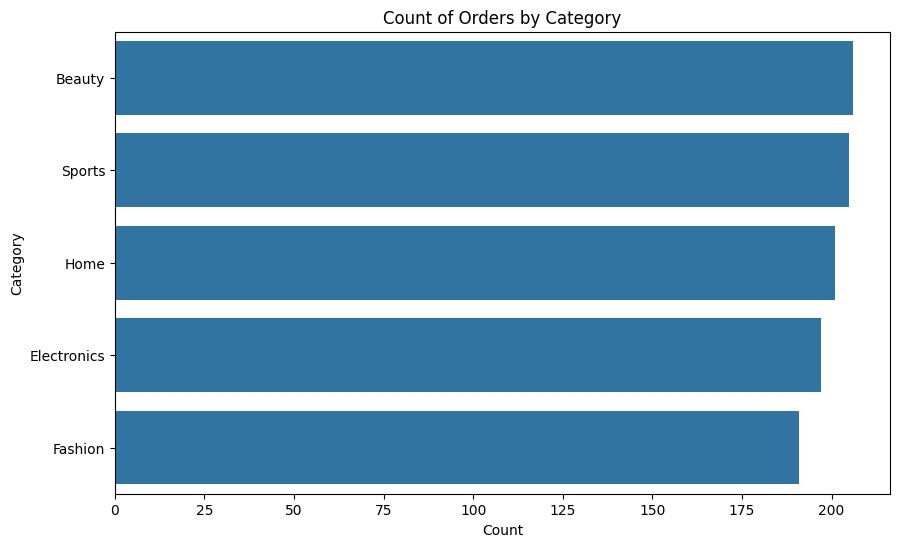

In [54]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='category', order=df['category'].value_counts().index)
plt.title('Count of Orders by Category')
plt.xlabel('Count')
plt.ylabel('Category')
plt.show()

## Visualization 2 - Region countplot
**Task:** Create a count plot for region.

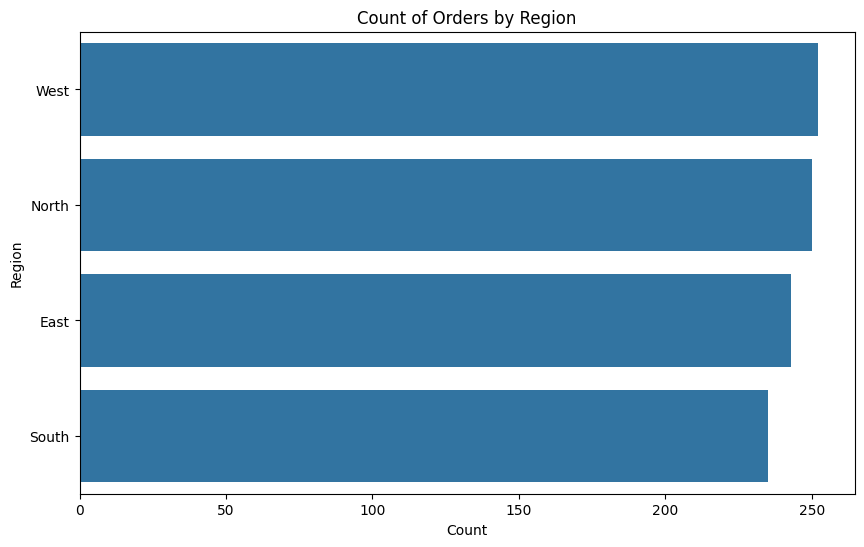

In [55]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='region', order=df['region'].value_counts().index)
plt.title('Count of Orders by Region')
plt.xlabel('Count')
plt.ylabel('Region')
plt.show()

## Visualization 3 - Payment method countplot
**Task:** Create a count plot for payment_method.

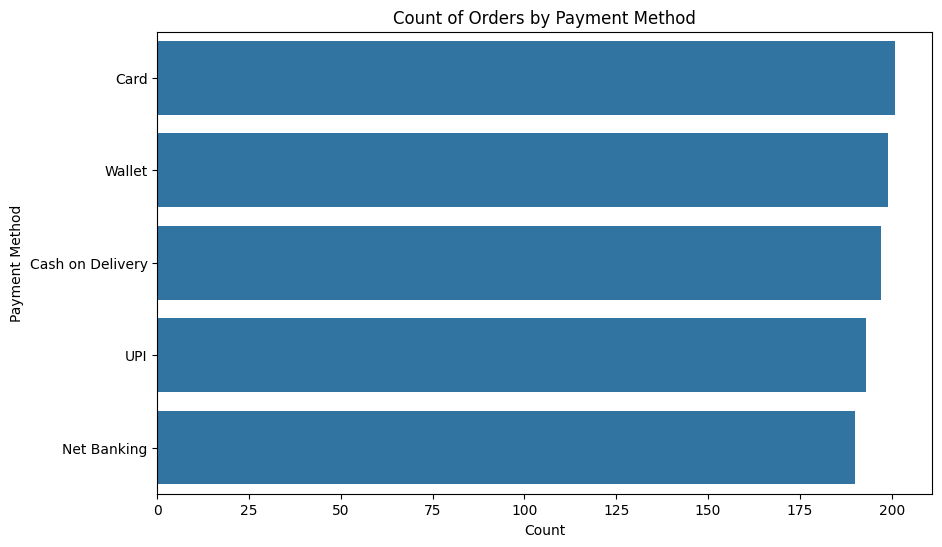

In [56]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='payment_method', order=df['payment_method'].value_counts().index)
plt.title('Count of Orders by Payment Method')
plt.xlabel('Count')
plt.ylabel('Payment Method')
plt.show()

## Visualization 4 - Unit price histogram
**Task:** Plot histogram for unit_price.

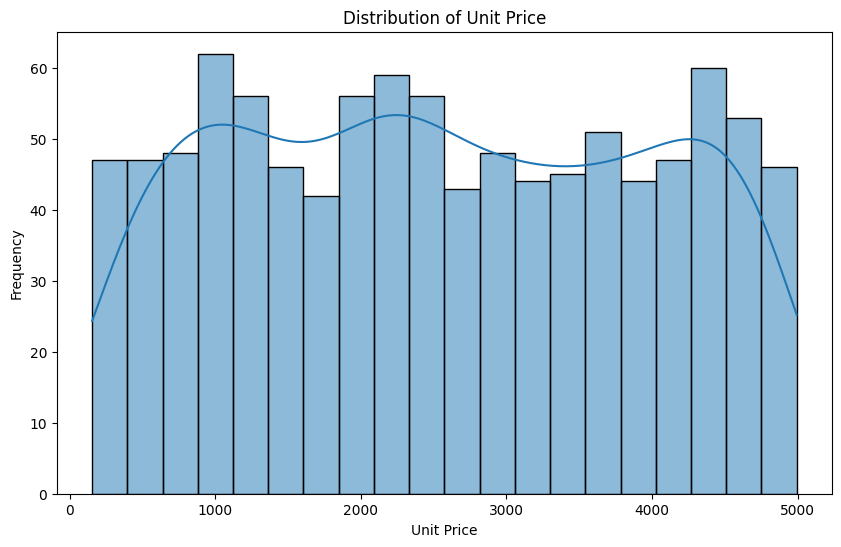

In [57]:
plt.figure(figsize=(10, 6))
sns.histplot(df['unit_price'], bins=20, kde=True)
plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price')
plt.ylabel('Frequency')
plt.show()

## Visualization 5 - Net amount histogram
**Task:** Plot histogram for net_amount.

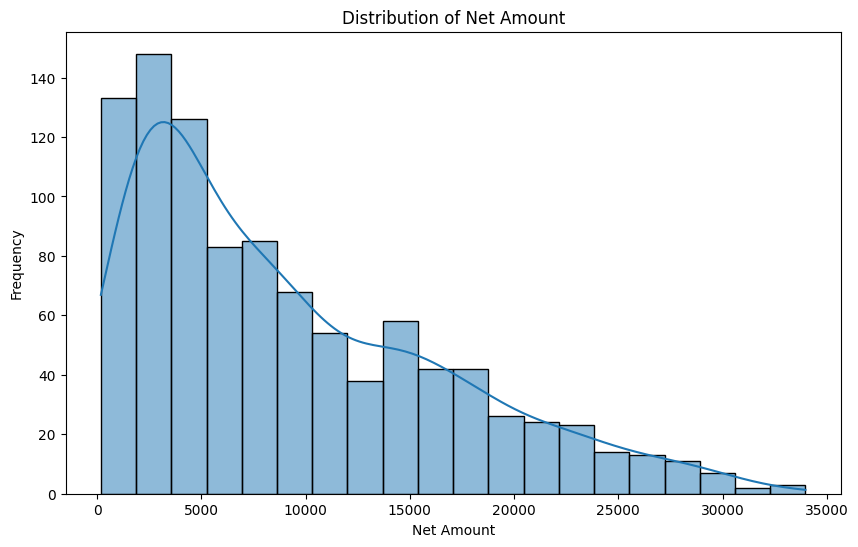

In [58]:
plt.figure(figsize=(10, 6))
sns.histplot(df['net_amount'], bins=20, kde=True)
plt.title('Distribution of Net Amount')
plt.xlabel('Net Amount')
plt.ylabel('Frequency')
plt.show()

## Visualization 6 - Boxplot by category
**Task:** Plot boxplot of net_amount by category.

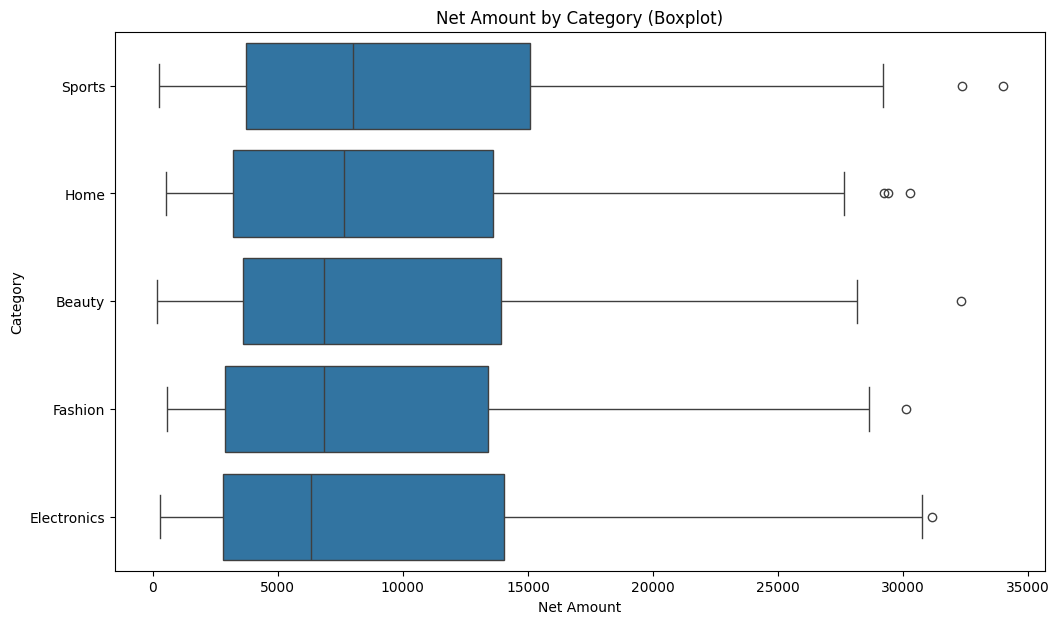

In [59]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='net_amount', y='category', order=df.groupby('category')['net_amount'].median().sort_values(ascending=False).index)
plt.title('Net Amount by Category (Boxplot)')
plt.xlabel('Net Amount')
plt.ylabel('Category')
plt.show()

## Visualization 7 - Bar chart of average net sales by category
**Task:** Use groupby result and plot bar chart.

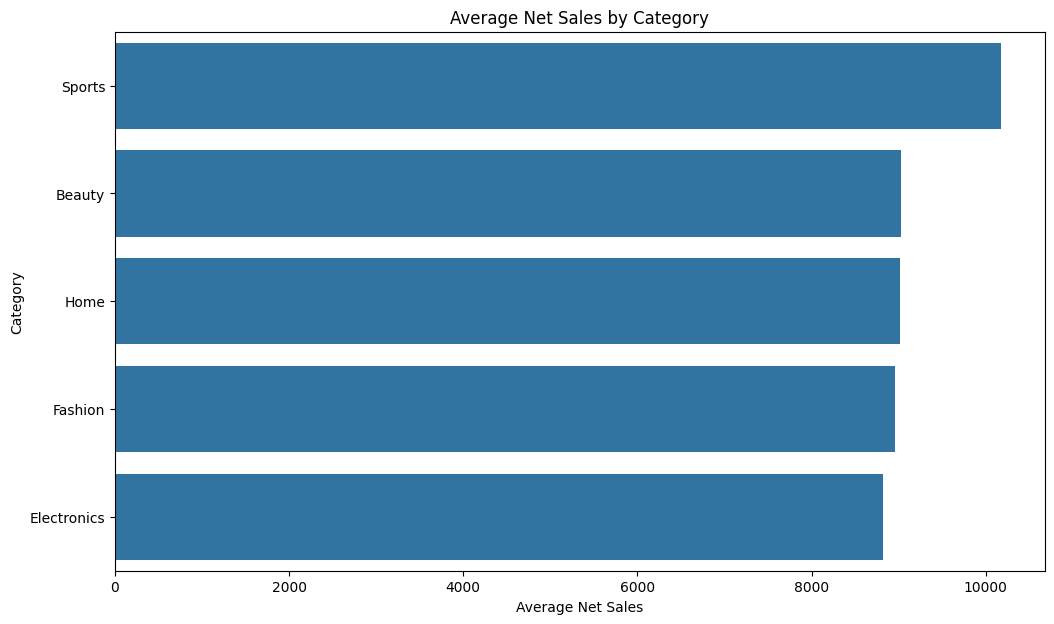

In [60]:
avg_net_sales_by_category = df.groupby('category')['net_amount'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(12, 7))
sns.barplot(data=avg_net_sales_by_category, x='net_amount', y='category')
plt.title('Average Net Sales by Category')
plt.xlabel('Average Net Sales')
plt.ylabel('Category')
plt.show()

## Visualization 8 - Monthly sales line chart
**Task:** Plot monthly total net_amount trend.

NameError: name 'monthly_sales_df' is not defined

<Figure size 1200x600 with 0 Axes>

## Visualization 9 - Heatmap correlation
**Task:** Plot heatmap for numeric correlations.

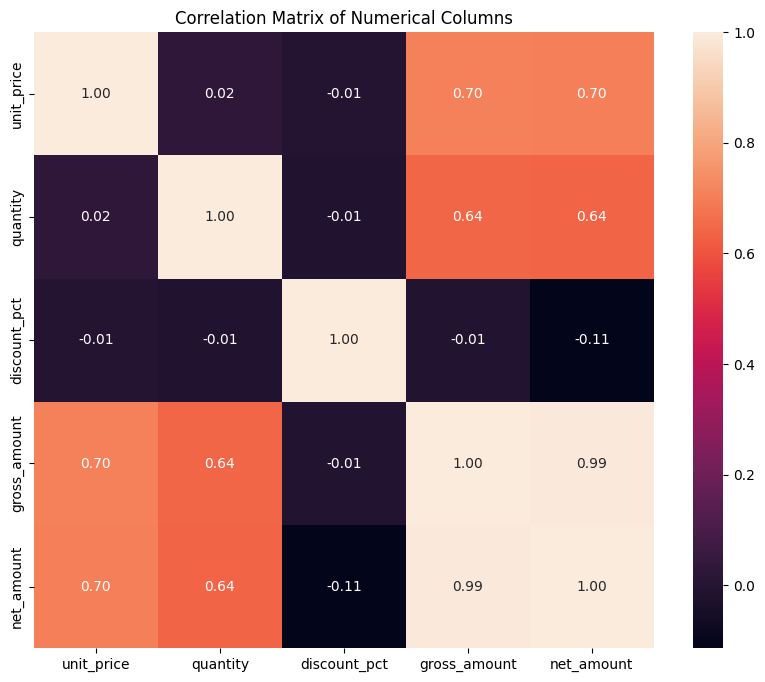

## Visualization 10 - Scatter plot
**Task:** Plot unit_price vs net_amount.

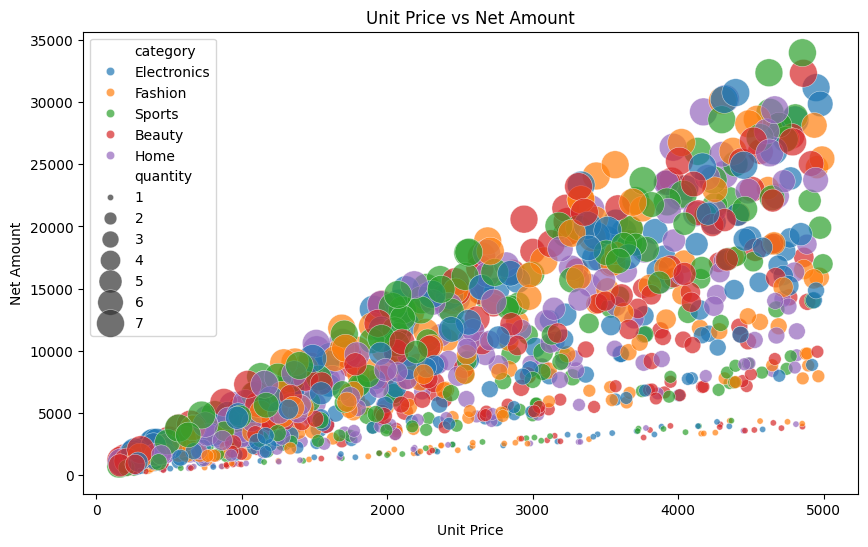

In [64]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='unit_price', y='net_amount', hue='category', size='quantity', sizes=(20, 400), alpha=0.7)
plt.title('Unit Price vs Net Amount')
plt.xlabel('Unit Price')
plt.ylabel('Net Amount')
plt.show()